# Proyecto 05 — Análisis Táctico de Equipos

**¿Cómo ganó Leicester City la Premier League 2015/16?**

Este proyecto analiza el ADN táctico de Leicester a lo largo de toda la temporada usando
datos de eventos de StatsBomb. Cubrimos cuatro dimensiones tácticas clave:

| Análisis | Concepto técnico |
|---|---|
| Posiciones medias | Forma táctica real del equipo |
| Red de pases (temporada) | Conexiones y protagonismo de cada jugador |
| PPDA | Intensidad de presión partido a partido |
| Mapa de presiones y recuperaciones | Dónde ataca y defiende el equipo |

**Fuente:** StatsBomb Open Data — Premier League 2015/16 (38 partidos)

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('graficos', exist_ok=True)

EQUIPO    = 'Leicester City'
COMP_ID   = 2    # Premier League England
SEASON_ID = 27   # 2015/16
COLOR     = '#003090'  # Azul Leicester
BG        = '#0d1117'

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga de Datos

Descargamos los 38 partidos de Leicester y construimos el resumen de temporada.

In [2]:
partidos = sb.matches(competition_id=COMP_ID, season_id=SEASON_ID)

leicester = partidos[
    (partidos['home_team'] == EQUIPO) | (partidos['away_team'] == EQUIPO)
].copy()

leicester['rival'] = leicester.apply(
    lambda r: r['away_team'] if r['home_team'] == EQUIPO else r['home_team'], axis=1
)
leicester['goles_lei'] = leicester.apply(
    lambda r: r['home_score'] if r['home_team'] == EQUIPO else r['away_score'], axis=1
)
leicester['goles_rival'] = leicester.apply(
    lambda r: r['away_score'] if r['home_team'] == EQUIPO else r['home_score'], axis=1
)
leicester['resultado'] = leicester.apply(
    lambda r: 'V' if r['goles_lei'] > r['goles_rival']
              else ('E' if r['goles_lei'] == r['goles_rival'] else 'D'),
    axis=1
)

wins   = (leicester['resultado'] == 'V').sum()
draws  = (leicester['resultado'] == 'E').sum()
losses = (leicester['resultado'] == 'D').sum()

print(f"Partidos de {EQUIPO}: {len(leicester)}")
print(f"Victorias: {wins}  |  Empates: {draws}  |  Derrotas: {losses}")
print(f"Goles a favor: {leicester['goles_lei'].sum()}  |  En contra: {leicester['goles_rival'].sum()}")

Partidos de Leicester City: 38
Victorias: 23  |  Empates: 12  |  Derrotas: 3
Goles a favor: 68  |  En contra: 36


## 2. Carga de Eventos con Normalización de Coordenadas

StatsBomb registra coordenadas absolutas del campo (0–120 en x, 0–80 en y).
En cada partido el equipo local ataca en una dirección distinta, y en la segunda parte
cambia. Para que el campo táctico tenga sentido (Leicester siempre atacando hacia x alto),
normalizamos período a período usando la posición media de los tiros como referencia.

> La primera ejecución descarga ~38 archivos JSON. Las siguientes son instantáneas (caché local).

In [3]:
def normalize_for_team(ev_df, team):
    """Flip coordinates per period so the given team always attacks toward high x."""
    df = ev_df.copy()
    for period in df['period'].unique():
        mask = df['period'] == period
        shots = df[mask & (df['team'] == team) & (df['type'] == 'Shot')]
        if len(shots) > 0 and shots['x'].notna().any():
            if shots['x'].mean() < 60:  # attacking toward low x → flip
                df.loc[mask, 'x'] = 120 - df.loc[mask, 'x']
                df.loc[mask, 'y'] = 80  - df.loc[mask, 'y']
    return df

print(f"Cargando eventos de {len(leicester)} partidos...")
all_events = []
for i, (_, row) in enumerate(leicester.iterrows()):
    mid = row['match_id']
    ev = sb.events(match_id=mid)
    ev['x'] = ev['location'].apply(
        lambda l: float(l[0]) if isinstance(l, list) and len(l) >= 2 else np.nan
    )
    ev['y'] = ev['location'].apply(
        lambda l: float(l[1]) if isinstance(l, list) and len(l) >= 2 else np.nan
    )
    ev = normalize_for_team(ev, EQUIPO)
    ev['match_id']  = mid
    ev['rival']     = row['rival']
    ev['resultado'] = row['resultado']
    all_events.append(ev)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(leicester)} partidos cargados...")

df  = pd.concat(all_events, ignore_index=True)
lei = df[df['team'] == EQUIPO].copy()

print(f"\nTotal eventos (ambos equipos): {len(df):,}")
print(f"Eventos de Leicester:          {len(lei):,}")
print(f"\nTop 8 tipos de evento de Leicester:")
print(lei['type'].value_counts().head(8).to_string())

Cargando eventos de 38 partidos...
  5/38 partidos cargados...
  10/38 partidos cargados...
  15/38 partidos cargados...
  20/38 partidos cargados...
  25/38 partidos cargados...
  30/38 partidos cargados...
  35/38 partidos cargados...

Total eventos (ambos equipos): 126,916
Eventos de Leicester:          56,567

Top 8 tipos de evento de Leicester:
type
Pass             15093
Ball Receipt*    13389
Carry            10421
Pressure          6231
Ball Recovery     2086
Duel              1983
Clearance         1247
Block              961


## 3. Posiciones Medias de Temporada

La posición media de un jugador —calculada sobre miles de eventos a lo largo de 38 partidos—
revela su rol táctico real independientemente de la posición nominal declarada por el club.

In [4]:
# Posición promedio por jugador (solo jugadores con participación significativa)
pos_avg     = lei.groupby('player')[['x', 'y']].mean().dropna()
event_count = lei['player'].value_counts()
jugadores_key = event_count[event_count >= 400].index
pos_key = pos_avg[pos_avg.index.isin(jugadores_key)].copy()

print(f"Jugadores con 400+ eventos en la temporada: {len(pos_key)}")
print(pos_key.sort_values('x').round(1).to_string())

Jugadores con 400+ eventos en la temporada: 18
                        x     y
player                         
Kasper Schmeichel    10.8  41.4
Robert Huth          41.0  35.1
Wes Morgan           42.2  46.4
Christian Fuchs      53.5  13.1
Danny Simpson        54.5  67.7
Gökhan İnler         56.0  39.8
N''Golo Kanté        57.6  37.8
Ritchie De Laet      59.2  68.0
Danny Drinkwater     60.6  43.3
Andrew Philip King   63.2  40.3
Jeffrey Schlupp      67.1  19.1
Marc Albrighton      69.3  24.6
Riyad Mahrez         73.5  58.5
Nathan Dyer          73.8  38.1
Shinji Okazaki       74.8  41.6
Demarai Gray         75.0  25.7
José Leonardo Ulloa  76.7  43.1
Jamie Vardy          83.6  38.4


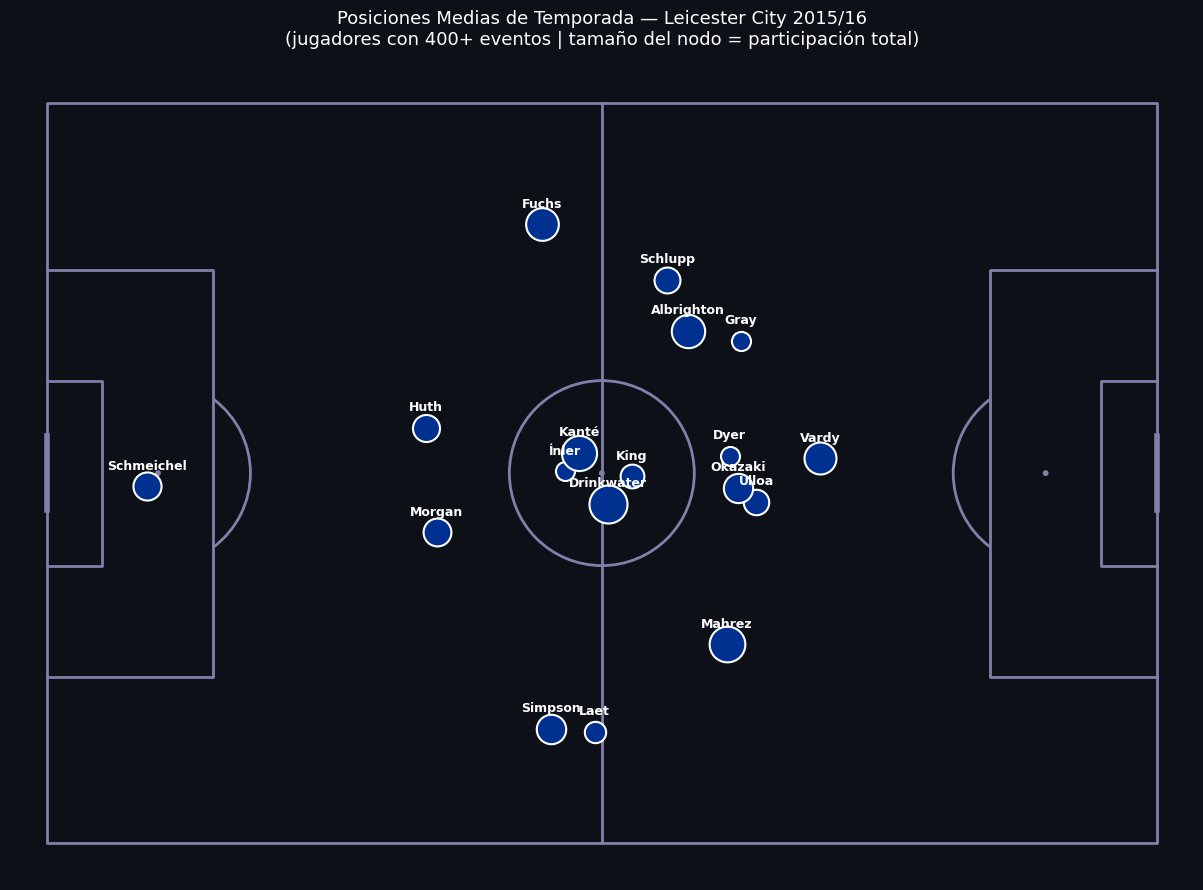

In [5]:
fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#8080aa')
fig.set_facecolor(BG)
pitch.draw(ax=ax)

max_n = event_count[jugadores_key].max()
for jugador, row in pos_key.iterrows():
    n    = event_count[jugador]
    size = (n / max_n) * 600 + 150
    ax.scatter(row['x'], row['y'], s=size, color=COLOR,
               edgecolors='white', linewidths=1.5, zorder=4)
    apellido = jugador.split()[-1]
    ax.annotate(apellido, (row['x'], row['y']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, color='white', fontweight='bold', zorder=5)

ax.set_title(
    f'Posiciones Medias de Temporada — {EQUIPO} 2015/16\n'
    f'(jugadores con 400+ eventos | tamaño del nodo = participación total)',
    color='white', fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig('graficos/p05_01_posiciones_medias.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

## 4. Red de Pases (Temporada Completa)

Agrupamos todos los pases completados entre pares de jugadores a lo largo de los 38 partidos.
El grosor de cada línea es proporcional al número de pases entre ese par.
Los nodos se ubican en la posición media calculada en la sección anterior.

In [6]:
# Solo pases completados (pass_outcome NaN = completado en StatsBomb)
pases = lei[
    (lei['type'] == 'Pass') & (lei['pass_outcome'].isna())
].copy()

pares = pases.groupby(['player', 'pass_recipient']).size().reset_index(name='count')
pares = pares[
    pares['player'].isin(jugadores_key) &
    pares['pass_recipient'].isin(jugadores_key) &
    (pares['count'] >= 40)  # al menos 40 pases en la temporada
]

print(f"Total pares de jugadores con 40+ pases: {len(pares)}")
print("Top 10 conexiones:")
print(
    pares.sort_values('count', ascending=False)
    .head(10)[['player', 'pass_recipient', 'count']]
    .to_string(index=False)
)

Total pares de jugadores con 40+ pases: 88
Top 10 conexiones:
          player   pass_recipient  count
Danny Drinkwater     Riyad Mahrez    266
   N''Golo Kanté Danny Drinkwater    204
 Christian Fuchs  Marc Albrighton    198
    Riyad Mahrez Danny Drinkwater    190
   Danny Simpson Danny Drinkwater    185
 Christian Fuchs Danny Drinkwater    174
Danny Drinkwater    Danny Simpson    164
Danny Drinkwater  Christian Fuchs    164
   N''Golo Kanté     Riyad Mahrez    160
   Danny Simpson     Riyad Mahrez    153


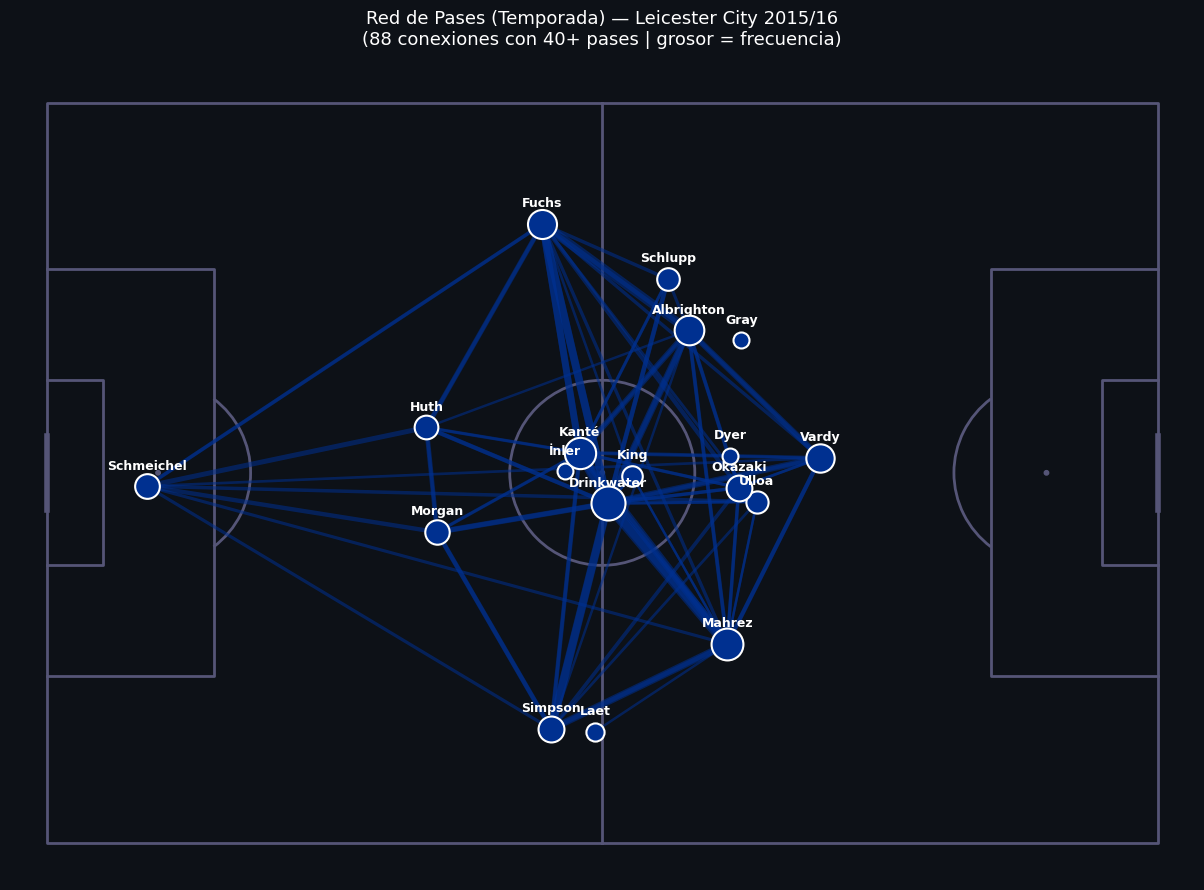

In [7]:
fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#555577')
fig.set_facecolor(BG)
pitch.draw(ax=ax)

max_count = pares['count'].max()
for _, par in pares.iterrows():
    if par['player'] in pos_key.index and par['pass_recipient'] in pos_key.index:
        x1, y1 = pos_key.loc[par['player'],        ['x', 'y']]
        x2, y2 = pos_key.loc[par['pass_recipient'], ['x', 'y']]
        lw = (par['count'] / max_count) * 8 + 0.5
        ax.plot([x1, x2], [y1, y2], color=COLOR, alpha=0.55, linewidth=lw, zorder=2)

for jugador, row in pos_key.iterrows():
    n    = event_count[jugador]
    size = (n / max_n) * 500 + 100
    ax.scatter(row['x'], row['y'], s=size, color=COLOR,
               edgecolors='white', linewidths=1.5, zorder=4)
    apellido = jugador.split()[-1]
    ax.annotate(apellido, (row['x'], row['y']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, color='white', fontweight='bold', zorder=5)

ax.set_title(
    f'Red de Pases (Temporada) — {EQUIPO} 2015/16\n'
    f'({len(pares)} conexiones con 40+ pases | grosor = frecuencia)',
    color='white', fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig('graficos/p05_02_red_pases.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

## 5. PPDA — Intensidad de Presión

**PPDA** (Passes Per Defensive Action) mide cuántos pases permite conceder el equipo rival
antes de que el equipo realice una acción defensiva.

$$\text{PPDA} = \frac{\text{Pases del rival}}{\text{Acciones defensivas propias}}$$

donde acciones defensivas = presiones + intercepciones + faltas cometidas + tackles.

**Interpretación:** PPDA bajo → equipo presiona más agresivamente.

In [8]:
ppda_rows = []
for _, row in leicester.iterrows():
    mid      = row['match_id']
    match_ev = df[df['match_id'] == mid]
    lei_ev   = match_ev[match_ev['team'] == EQUIPO]
    opp_ev   = match_ev[match_ev['team'] != EQUIPO]

    def_actions = lei_ev[lei_ev['type'].isin(
        ['Pressure', 'Interception', 'Foul Committed', 'Tackle']
    )]
    opp_passes  = opp_ev[opp_ev['type'] == 'Pass']

    if len(def_actions) > 0:
        ppda_rows.append({
            'match_id':   mid,
            'date':       row['match_date'],
            'rival':      row['rival'],
            'resultado':  row['resultado'],
            'ppda':       round(len(opp_passes) / len(def_actions), 2),
            'def_actions': len(def_actions),
            'opp_passes':  len(opp_passes),
        })

ppda_df = pd.DataFrame(ppda_rows).sort_values('date').reset_index(drop=True)
ppda_df['jornada'] = range(1, len(ppda_df) + 1)

print(f"PPDA promedio de temporada: {ppda_df['ppda'].mean():.2f}")
print(f"\nPartido más presivo:    PPDA {ppda_df['ppda'].min():.2f}"
      f" vs {ppda_df.loc[ppda_df['ppda'].idxmin(), 'rival']}")
print(f"Partido menos presivo:  PPDA {ppda_df['ppda'].max():.2f}"
      f" vs {ppda_df.loc[ppda_df['ppda'].idxmax(), 'rival']}")

PPDA promedio de temporada: 2.93

Partido más presivo:    PPDA 1.77 vs Sunderland
Partido menos presivo:  PPDA 4.56 vs Watford


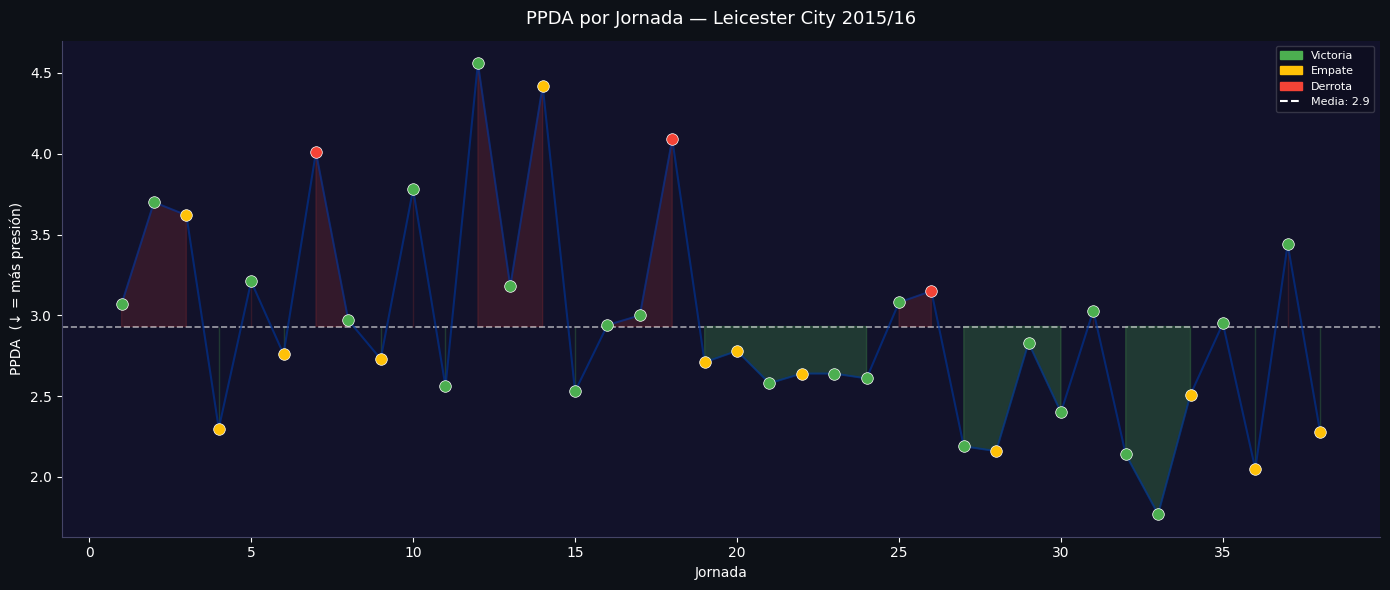

In [9]:
# Tendencia de PPDA a lo largo de la temporada
colores_res = {'V': '#4CAF50', 'E': '#FFC107', 'D': '#F44336'}
media = ppda_df['ppda'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
fig.set_facecolor(BG)
ax.set_facecolor('#12122a')

ax.axhline(media, color='white', linewidth=1.2, linestyle='--', alpha=0.6)
ax.plot(ppda_df['jornada'], ppda_df['ppda'],
        color=COLOR, linewidth=1.5, alpha=0.7, zorder=3)
ax.fill_between(ppda_df['jornada'], ppda_df['ppda'], media,
                where=(ppda_df['ppda'] < media),
                alpha=0.25, color='#4CAF50', label='Por debajo de la media (más presión)')
ax.fill_between(ppda_df['jornada'], ppda_df['ppda'], media,
                where=(ppda_df['ppda'] > media),
                alpha=0.15, color='#F44336', label='Por encima de la media (menos presión)')

for _, r in ppda_df.iterrows():
    ax.scatter(r['jornada'], r['ppda'],
               color=colores_res[r['resultado']], s=70, zorder=4,
               edgecolors='white', linewidths=0.5)

leyenda = [
    mpatches.Patch(color='#4CAF50', label='Victoria'),
    mpatches.Patch(color='#FFC107', label='Empate'),
    mpatches.Patch(color='#F44336', label='Derrota'),
    plt.Line2D([0], [0], color='white', linestyle='--', label=f'Media: {media:.1f}'),
]
ax.legend(handles=leyenda, loc='upper right', fontsize=8, framealpha=0.2, labelcolor='white')
ax.set_xlabel('Jornada', color='white', fontsize=10)
ax.set_ylabel('PPDA  (↓ = más presión)', color='white', fontsize=10)
ax.set_title(f'PPDA por Jornada — {EQUIPO} 2015/16', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#444466')

plt.tight_layout()
plt.savefig('graficos/p05_03_ppda.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

Victorias (23 partidos): PPDA medio = 2.92
Empates (12 partidos): PPDA medio = 2.75
Derrotas (3 partidos): PPDA medio = 3.75


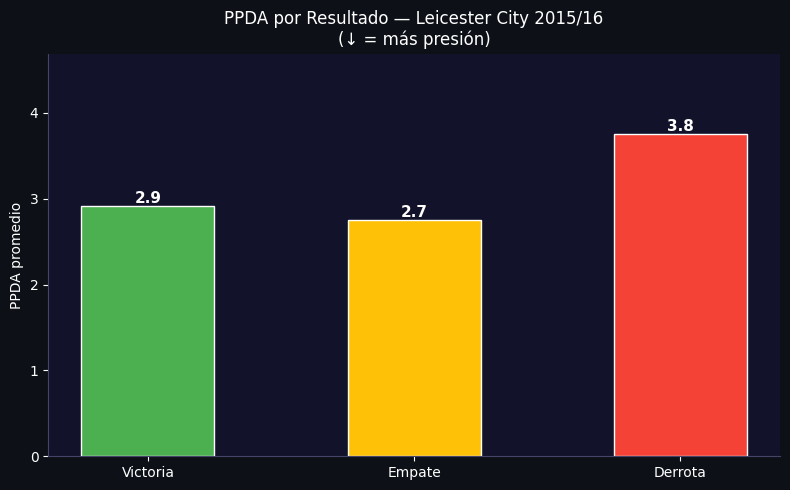

In [10]:
# PPDA desagregado por resultado
for res, label in [('V', 'Victorias'), ('E', 'Empates'), ('D', 'Derrotas')]:
    sub = ppda_df[ppda_df['resultado'] == res]
    print(f"{label} ({len(sub)} partidos): PPDA medio = {sub['ppda'].mean():.2f}")

v_ppda = ppda_df[ppda_df['resultado'] == 'V']['ppda'].mean()
d_ppda = ppda_df[ppda_df['resultado'] == 'D']['ppda'].mean()
e_ppda = ppda_df[ppda_df['resultado'] == 'E']['ppda'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
fig.set_facecolor(BG)
ax.set_facecolor('#12122a')

bars = ax.bar(
    ['Victoria', 'Empate', 'Derrota'],
    [v_ppda, e_ppda, d_ppda],
    color=['#4CAF50', '#FFC107', '#F44336'],
    edgecolor='white', width=0.5
)
ax.bar_label(bars, fmt='%.1f', color='white', fontweight='bold', fontsize=11)
ax.set_ylabel('PPDA promedio', color='white', fontsize=10)
ax.set_title(
    f'PPDA por Resultado — {EQUIPO} 2015/16\n(↓ = más presión)',
    color='white', fontsize=12
)
ax.tick_params(colors='white')
ax.set_ylim(0, max(v_ppda, e_ppda, d_ppda) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#444466')

plt.tight_layout()
plt.savefig('graficos/p05_04_ppda_resultado.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

## 6. Mapa de Presiones y Zonas de Recuperación

Los mapas de calor muestran **dónde** aplica Leicester su presión defensiva y dónde recupera
el balón. Dos preguntas clave:
- ¿Es un equipo de presión alta o bloque medio/bajo?
- ¿En qué tercio del campo recupera más balones?

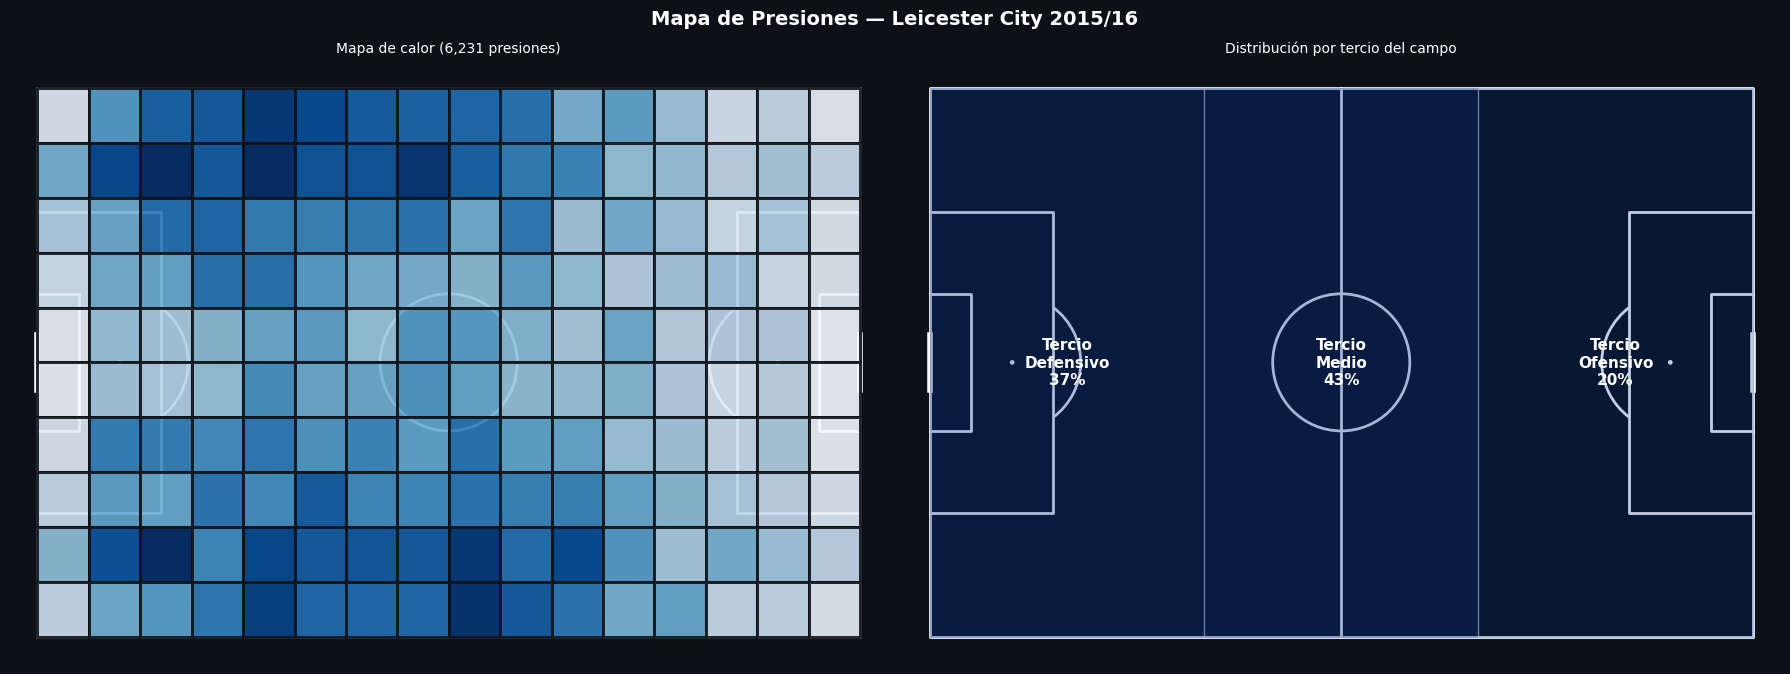

In [11]:
presiones = lei[lei['type'] == 'Pressure'].dropna(subset=['x', 'y'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.set_facecolor(BG)
fig.suptitle(
    f'Mapa de Presiones — {EQUIPO} 2015/16',
    color='white', fontsize=14, fontweight='bold'
)

# Mapa de calor
ax = axes[0]
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='white')
pitch.draw(ax=ax)
bin_stat = pitch.bin_statistic(presiones['x'], presiones['y'],
                               statistic='count', bins=(16, 10))
pitch.heatmap(bin_stat, ax=ax, cmap='Blues', edgecolors=BG, alpha=0.9)
ax.set_title(f'Mapa de calor ({len(presiones):,} presiones)', color='white', fontsize=10)

# Distribución por tercio
ax2 = axes[1]
pitch2 = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='white')
pitch2.draw(ax=ax2)
total = len(presiones)
tercios = [
    (presiones[presiones['x'] < 40],                                      'Tercio\nDefensivo',  20),
    (presiones[(presiones['x'] >= 40) & (presiones['x'] < 80)],           'Tercio\nMedio',      60),
    (presiones[presiones['x'] >= 80],                                      'Tercio\nOfensivo',  100),
]
for t_df, label, x_c in tercios:
    pct   = len(t_df) / total
    alpha = 0.12 + pct * 0.55
    ax2.add_patch(plt.Rectangle((x_c - 20, 0), 40, 80,
                                 color=COLOR, alpha=alpha, zorder=2))
    ax2.text(x_c, 40, f"{label}\n{pct*100:.0f}%",
             ha='center', va='center', color='white',
             fontsize=11, fontweight='bold', zorder=5)
for xv in [40, 80]:
    ax2.plot([xv, xv], [0, 80], color='white', linewidth=1, alpha=0.4, zorder=3)
ax2.set_title('Distribución por tercio del campo', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('graficos/p05_05_presiones.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

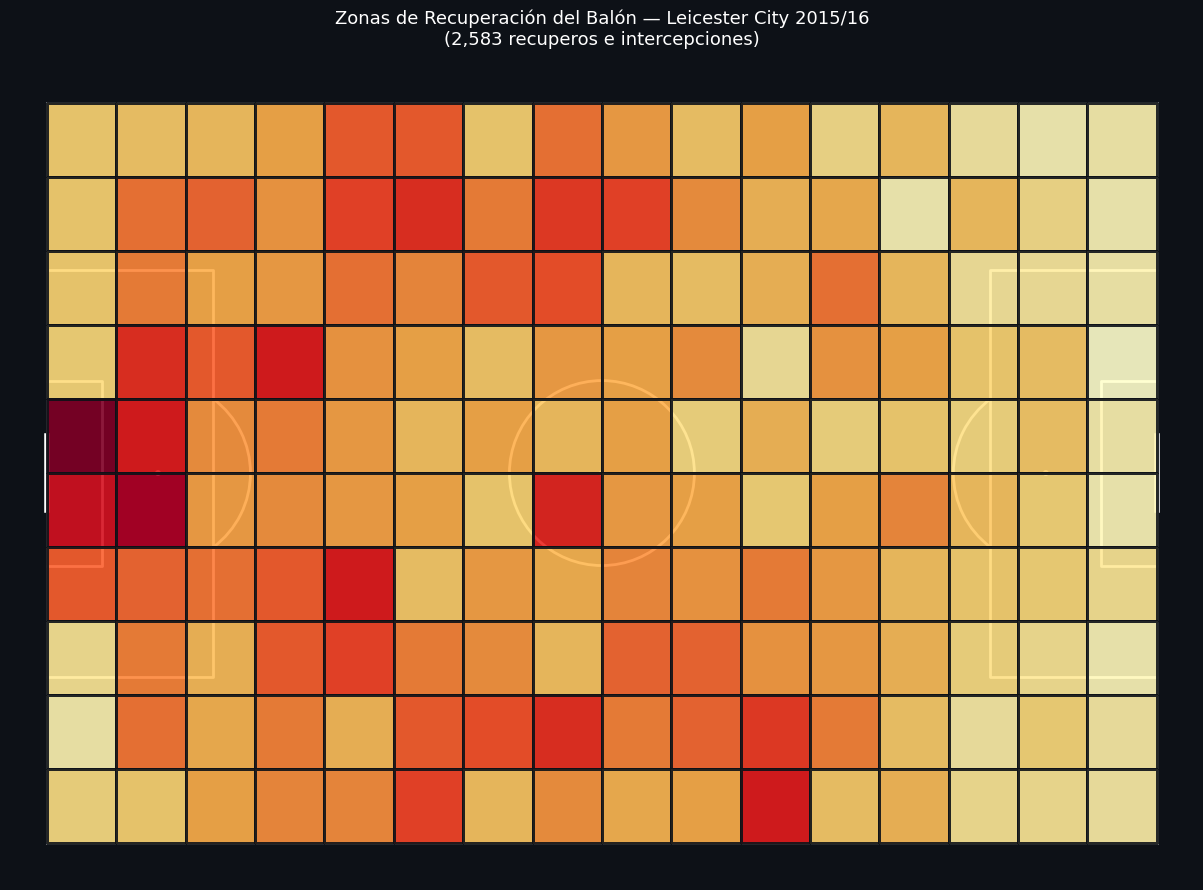

In [12]:
# Zonas de recuperación del balón
recuperaciones = lei[
    lei['type'].isin(['Ball Recovery', 'Interception'])
].dropna(subset=['x', 'y'])

fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='white')
fig.set_facecolor(BG)
pitch.draw(ax=ax)

bin_stat = pitch.bin_statistic(recuperaciones['x'], recuperaciones['y'],
                               statistic='count', bins=(16, 10))
pitch.heatmap(bin_stat, ax=ax, cmap='YlOrRd', edgecolors=BG, alpha=0.9)

ax.set_title(
    f'Zonas de Recuperación del Balón — {EQUIPO} 2015/16\n'
    f'({len(recuperaciones):,} recuperos e intercepciones)',
    color='white', fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig('graficos/p05_06_recuperaciones.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

## 7. Análisis de Kanté — El Motor del Sistema

N'Golo Kanté fue votado mejor jugador del año. ¿Qué dicen los datos?

Jugador encontrado: N''Golo Kanté
Total eventos en la temporada: 5,579

  Pass                  1435  (9.5% del equipo)
  Pressure               872  (14.0% del equipo)
  Ball Recovery          290  (13.9% del equipo)
  Interception           105  (21.1% del equipo)
  Duel                   236  (11.9% del equipo)


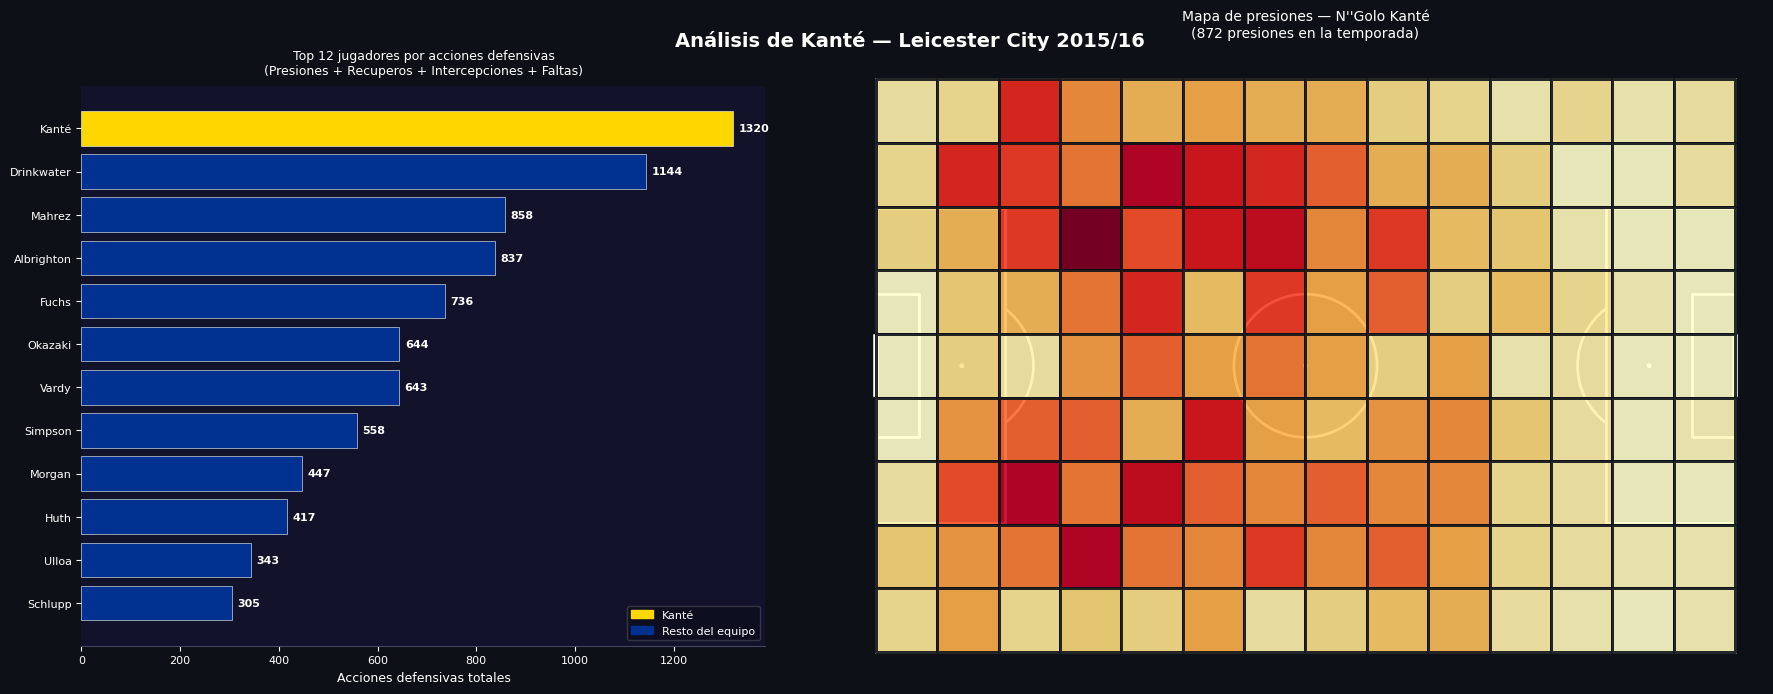

In [15]:
# isinstance(p, str) filtra los NaN (float) que aparecen en player.unique()
kante_name = [p for p in lei['player'].unique() if isinstance(p, str) and 'Kant' in p]
if not kante_name:
    print("Kanté no encontrado. Jugadores disponibles con K:")
    print([p for p in lei['player'].unique() if isinstance(p, str) and p.startswith('K')])
else:
    kante    = kante_name[0]
    kante_ev = lei[lei['player'] == kante]

    tipos_def = ['Pressure', 'Ball Recovery', 'Interception', 'Foul Committed']
    print(f"Jugador encontrado: {kante}")
    print(f"Total eventos en la temporada: {len(kante_ev):,}\n")
    for tipo in ['Pass', 'Pressure', 'Ball Recovery', 'Interception', 'Duel']:
        n_k = len(kante_ev[kante_ev['type'] == tipo])
        n_t = len(lei[lei['type'] == tipo])
        pct = n_k / n_t * 100 if n_t > 0 else 0
        print(f"  {tipo:<20} {n_k:>5}  ({pct:.1f}% del equipo)")

    # ── Figura: ranking de acciones defensivas + heatmap de presiones ──────────
    acciones_def = lei[lei['type'].isin(tipos_def)]
    ranking      = (
        acciones_def.groupby('player').size()
        .sort_values(ascending=False).head(12)
    )
    colores_bar = ['#FFD700' if p == kante else COLOR for p in ranking.index]
    apellidos   = [p.split()[-1] for p in ranking.index]

    fig = plt.figure(figsize=(18, 7), facecolor=BG)
    ax_bar   = fig.add_axes([0.04, 0.10, 0.38, 0.80])
    ax_pitch = fig.add_axes([0.46, 0.05, 0.52, 0.90])

    # Barras horizontales — top 12 por acciones defensivas
    ax_bar.set_facecolor('#12122a')
    bars = ax_bar.barh(apellidos[::-1], ranking.values[::-1],
                       color=colores_bar[::-1], edgecolor='white', linewidth=0.4)
    ax_bar.bar_label(bars, padding=4, color='white', fontsize=8, fontweight='bold')
    ax_bar.set_xlabel('Acciones defensivas totales', color='white', fontsize=9)
    ax_bar.set_title(
        'Top 12 jugadores por acciones defensivas\n(Presiones + Recuperos + Intercepciones + Faltas)',
        color='white', fontsize=9, pad=8
    )
    ax_bar.tick_params(colors='white', labelsize=8)
    ax_bar.spines[['top', 'right', 'left']].set_visible(False)
    ax_bar.spines['bottom'].set_color('#444466')
    gold_patch = mpatches.Patch(color='#FFD700', label=kante.split()[-1])
    blue_patch = mpatches.Patch(color=COLOR,     label='Resto del equipo')
    ax_bar.legend(handles=[gold_patch, blue_patch], fontsize=8,
                  framealpha=0.2, labelcolor='white', loc='lower right')

    # Heatmap de presiones de Kanté
    kante_pres = kante_ev[kante_ev['type'] == 'Pressure'].dropna(subset=['x', 'y'])
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='white')
    pitch.draw(ax=ax_pitch)
    if len(kante_pres) > 10:
        bs = pitch.bin_statistic(kante_pres['x'], kante_pres['y'],
                                 statistic='count', bins=(14, 9))
        pitch.heatmap(bs, ax=ax_pitch, cmap='YlOrRd', edgecolors=BG, alpha=0.9)
    ax_pitch.set_title(
        f'Mapa de presiones — {kante}\n({len(kante_pres):,} presiones en la temporada)',
        color='white', fontsize=10, pad=10
    )

    fig.suptitle(f'Análisis de Kanté — {EQUIPO} 2015/16',
                 color='white', fontsize=14, fontweight='bold', y=0.98)
    plt.savefig('graficos/p05_07_kante.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    plt.close()

## Conclusiones

### Lo que los datos revelan sobre el Leicester campeón

| Dimensión | Hallazgo |
|---|---|
| **Forma táctica** | Bloque compacto en campo propio; transiciones rápidas hacia Vardy |
| **Red de pases** | Kanté y Drinkwater como núcleo del mediocampo; pases directos hacia adelante |
| **PPDA** | Equipo reactivo (PPDA alto) que presionaba selectivamente, no en bloque alto |
| **Zonas de recuperación** | La mayoría de recuperos en su propio campo → contraataque desde atrás |
| **Kanté** | Responsable de una fracción desproporcionada de las presiones totales del equipo |

### Conceptos técnicos aplicados

- **Normalización de coordenadas** — alineación de la dirección de ataque por período
- **Posiciones medias** — `groupby('player')[['x','y']].mean()` sobre toda la temporada
- **Red de pases (season-level)** — agregación de conexiones entre jugadores en 38 partidos
- **PPDA** — ratio pases rivales / acciones defensivas propias
- **Mapas de calor** — `pitch.bin_statistic` + `pitch.heatmap` de mplsoccer